In [749]:
import numpy as np

In [750]:
x=np.array([2])
w=np.array([3])
y=x**2
y+=1
x

array([2])

In [751]:
d1 = {1: 1, 2: 2}
d2 = {4: 'ha!', 3: 3}
d1['d2'] = d2
d1

{1: 1, 2: 2, 'd2': {4: 'ha!', 3: 3}}

In [752]:
import torch
t=torch.tensor([[2,2,4],[1,1,9]])
t=t.unsqueeze(2)
t=t.unsqueeze(3)
t=t.repeat((1,1,3,3))
t.shape

torch.Size([2, 3, 3, 3])

In [753]:
t=torch.tensor([[1,0,0],[0,1,0],[0,0,1],[0,1,0],[0,0,1],[0,0,1],[1,0,0],[0,1,0],[1,0,0],[0,1,0],[0,0,1],[0,1,0],[0,0,1],[0,0,1],[1,0,0],[0,1,0]])

In [754]:
t

tensor([[1, 0, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 1, 0],
        [0, 0, 1],
        [0, 0, 1],
        [1, 0, 0],
        [0, 1, 0],
        [1, 0, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 1, 0],
        [0, 0, 1],
        [0, 0, 1],
        [1, 0, 0],
        [0, 1, 0]])

In [755]:
x=t[:,0]==1
i=x.nonzero().squeeze().tolist()
i

[0, 6, 8, 14]

In [756]:
m=t.shape[1]
L=[]
i=t.nonzero()
for j in range(m):
    l=i[i[:,1]==j][:,0].tolist()
    print(l)
    L.append(l)
print(L)

[0, 6, 8, 14]
[1, 3, 7, 9, 11, 15]
[2, 4, 5, 10, 12, 13]
[[0, 6, 8, 14], [1, 3, 7, 9, 11, 15], [2, 4, 5, 10, 12, 13]]


In [757]:
from numpy import linalg as LA
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

W=np.array([[3,3,4,5],
[6,0,7,8],
[0,9,10,11],
[12,13,0,0]])


Pin2=np.array([[0,0,1],
[1,0,0],
[0,1,0],
[1,0,0]])

Pin=np.array([[1,0,0],
[0,1,0],
[0,0,1],
[1,0,0]])

C=np.array([[0,19,5],
[7,0,3],
[1,11,0]])

Pout=np.array([[0,1,0],
[0,1,0],
[0,0,1],
[1,0,0]])

#all parents
P3=Pin+Pin2
P3[P3!=0]=1
print(P3)

pr=1/2


E=W**2
needs=E@P3
needs=np.sqrt((needs))
print(needs)
row_l2_norm = LA.norm(W[:,[0,1,3]], axis=1)
print(row_l2_norm)

total=needs.shape[0]*needs.shape[1]
keep=(1-pr)*total
aligned_keep=needs.shape[0]
misaligned_keep=keep-aligned_keep
misaligned_total=total-aligned_keep
apr=misaligned_keep/total
print(total,keep,aligned_keep,misaligned_keep,misaligned_total,apr)

c2=1-Pout
print("c2", c2)
res1=needs*c2
print("res1", res1)
t=torch.quantile(torch.from_numpy(res1), 1-apr).item()
print(t)
res1[res1>t]=1
res1[res1!=1]=0
print(res1)
res1=res1+Pout
print(res1)
mask=res1@np.transpose(P3)
mask[mask!=0]=1
print(mask)






[[1 0 1]
 [1 1 0]
 [0 1 1]
 [1 0 0]]
[[ 6.55743852  5.          5.        ]
 [10.          7.          9.21954446]
 [14.2126704  13.45362405 10.        ]
 [17.69180601 13.         12.        ]]
[ 6.55743852 10.         14.2126704  17.69180601]
12 6.0 4 2.0 8 0.16666666666666666
c2 [[1 0 1]
 [1 0 1]
 [1 1 0]
 [0 1 1]]
res1 [[ 6.55743852  0.          5.        ]
 [10.          0.          9.21954446]
 [14.2126704  13.45362405  0.        ]
 [ 0.         13.         12.        ]]
13.07560400784562
[[0. 0. 0.]
 [0. 0. 0.]
 [1. 1. 0.]
 [0. 0. 0.]]
[[0. 1. 0.]
 [0. 1. 0.]
 [1. 1. 1.]
 [1. 0. 0.]]
[[0. 1. 1. 0.]
 [0. 1. 1. 0.]
 [1. 1. 1. 1.]
 [1. 1. 0. 1.]]


In [758]:
#test
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

W=np.array([[3,3,4,5],
[6,0,7,8],
[0,9,10,11],
[12,13,0,0]])


Pin2=np.array([[0,0,1],
[1,0,0],
[0,1,0],
[1,0,0]])

Pin=np.array([[1,0,0],
[0,1,0],
[0,0,1],
[1,0,0]])

C=np.array([[0,19,5],
[7,0,3],
[1,11,0]])

Pout=np.array([[0,1,0],
[0,1,0],
[0,0,1],
[1,0,0]])

E=torch.from_numpy(E).float()
W=torch.from_numpy(W).float()
Pin=torch.from_numpy(Pin).float()
Pin2=torch.from_numpy(Pin2).float()
Pout=torch.from_numpy(Pout).float()
C=torch.from_numpy(C).float()

P=Pin+Pin2
P[P!=0]=1

prune_ratio=0.5
print(P)
print(W)
E=W**2

needs=torch.sqrt(E@P)
#W[W!=0]=1
needs=W@P
print(needs)


#adjust semantics pr is ratio of pruned to total
total=needs.shape[0]*needs.shape[1]
aligned_keep=needs.shape[0]
misaligned_total=total-aligned_keep

misaligned_keep=(1-prune_ratio)*misaligned_total            
apr=misaligned_keep/total

c2=1-Pout
res1=needs*c2
print(Pout)
print(res1)

t=torch.quantile(res1, 1-apr) 
res1[res1>t]=1
res1[res1!=1]=0
res1=res1+Pout
print(res1)

mask=res1@torch.transpose(P,0,1)
mask[mask!=0]=1
print(mask)


res2=1-res1
print(res2)

mask2=res2@torch.transpose(P,0,1)
mask2[mask2!=0]=1
mask2=1-mask2
print(mask2)


tensor([[1., 0., 1.],
        [1., 1., 0.],
        [0., 1., 1.],
        [1., 0., 0.]])
tensor([[ 3.,  3.,  4.,  5.],
        [ 6.,  0.,  7.,  8.],
        [ 0.,  9., 10., 11.],
        [12., 13.,  0.,  0.]])
tensor([[11.,  7.,  7.],
        [14.,  7., 13.],
        [20., 19., 10.],
        [25., 13., 12.]])
tensor([[0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [1., 0., 0.]])
tensor([[11.,  0.,  7.],
        [14.,  0., 13.],
        [20., 19.,  0.],
        [ 0., 13., 12.]])
tensor([[0., 1., 0.],
        [1., 1., 0.],
        [1., 1., 1.],
        [1., 0., 0.]])
tensor([[0., 1., 1., 0.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 0., 1.]])
tensor([[1., 0., 1.],
        [0., 0., 1.],
        [0., 0., 0.],
        [0., 1., 1.]])
tensor([[0., 0., 0., 0.],
        [0., 1., 0., 1.],
        [1., 1., 1., 1.],
        [0., 0., 0., 1.]])


In [759]:
#test 2
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

W=np.array([[3,3,4,5],
[6,0,7,8],
[0,9,10,11],
[12,13,0,0]])


Pin2=np.array([[0,0,1],
[1,0,0],
[0,1,0],
[1,0,0]])

Pin=np.array([[1,0,0],
[0,1,0],
[0,0,1],
[1,0,0]])

C=np.array([[0,19,5],
[7,0,3],
[1,11,0]])

Pout=np.array([[0,1,0],
[0,1,0],
[0,0,1],
[1,0,0]])

E=torch.from_numpy(E).float()
W=torch.from_numpy(W).float()
Pin=torch.from_numpy(Pin).float()
Pin2=torch.from_numpy(Pin2).float()
Pout=torch.from_numpy(Pout).float()
C=torch.from_numpy(C).float()

P=Pin+Pin2
P[P!=0]=1

prune_ratio=0.5
print(P)
print(W)
E=W**2

needs=torch.sqrt(E@P)
#W[W!=0]=1
needs=W@P
print(needs)


#adjust semantics pr is ratio of pruned to total
total=needs.shape[0]*needs.shape[1]
aligned_keep=needs.shape[0]
misaligned_total=total-aligned_keep

misaligned_keep=(1-prune_ratio)*misaligned_total            
apr=misaligned_keep/total

c2=1-Pout
res1=needs*c2
print(Pout)
print(res1)

t=torch.quantile(res1, 1-apr) 
res1[res1>t]=1
res1[res1!=1]=0
res1=res1+Pout
print(res1)

mask=res1@torch.transpose(P,0,1)
mask[mask!=0]=1
print(mask)


res2=1-res1
print(res2)

mask2=res2@torch.transpose(P,0,1)
mask2[mask2!=0]=1
mask2=1-mask2
print(mask2)


print("!!!!!!!")
W2=W*mask2
zeros=0
total=0
zerosp=0
totalp=0
E=W2
E[E!=0]=1
print(E)
(n1,n2)=E.shape
total=n1*n2
zeros=total-E.sum()
print(zeros)
print("kernels",total,zeros,zeros/total)
#lin alg
needs=E@P
needs[needs!=0]=1
print(needs)
(n,m)=needs.shape
totalp=n*m
zerosp=totalp-needs.sum()
print("rows",totalp,zerosp,zerosp/totalp)

c2=1-Pout
offneeds=needs*c2
offtotalp=totalp-n
offzerosp=offtotalp-offneeds.sum()
print("off rows",offtotalp,offzerosp,offzerosp/offtotalp)
print(prune_ratio)


tensor([[1., 0., 1.],
        [1., 1., 0.],
        [0., 1., 1.],
        [1., 0., 0.]])
tensor([[ 3.,  3.,  4.,  5.],
        [ 6.,  0.,  7.,  8.],
        [ 0.,  9., 10., 11.],
        [12., 13.,  0.,  0.]])
tensor([[11.,  7.,  7.],
        [14.,  7., 13.],
        [20., 19., 10.],
        [25., 13., 12.]])
tensor([[0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [1., 0., 0.]])
tensor([[11.,  0.,  7.],
        [14.,  0., 13.],
        [20., 19.,  0.],
        [ 0., 13., 12.]])
tensor([[0., 1., 0.],
        [1., 1., 0.],
        [1., 1., 1.],
        [1., 0., 0.]])
tensor([[0., 1., 1., 0.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 0., 1.]])
tensor([[1., 0., 1.],
        [0., 0., 1.],
        [0., 0., 0.],
        [0., 1., 1.]])
tensor([[0., 0., 0., 0.],
        [0., 1., 0., 1.],
        [1., 1., 1., 1.],
        [0., 0., 0., 1.]])
!!!!!!!
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 1.],
        [0., 1., 1., 1.],
        [0., 0., 0., 0.]]

In [760]:
#test 2
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

W=np.array([[3,3,4,5],
[6,0,7,8],
[0,9,10,11],
[12,13,0,0]])


Pin2=np.array([[0,0,1],
[1,0,0],
[0,1,0],
[1,0,0]])

Pin=np.array([[1,0,0],
[0,1,0],
[0,0,1],
[1,0,0]])

C=np.array([[0,19,5],
[7,0,3],
[1,11,0]])

Pout=np.array([[0,1,0],
[0,1,0],
[0,0,1],
[1,0,0]])

E=torch.from_numpy(E).float()
W=torch.from_numpy(W).float()
Pin=torch.from_numpy(Pin).float()
Pin2=torch.from_numpy(Pin2).float()
Pout=torch.from_numpy(Pout).float()
C=torch.from_numpy(C).float()


print(W)
parents=[1,2]
layer_name=3
P={}
P[1]=Pin
P[2]=Pin2
P[3]=Pout
comm_costs=0
for parent in parents:
    #print(ra.P[parent].shape)
    #print(ra.C.shape)
    #print(torch.transpose(ra.P[layer_name],0,1).shape )
    #print(ADMM.P[parent].device,C.device,ADMM.P[layer_name].device)
    cc=P[parent] @ C @ torch.transpose(P[layer_name],0,1)   
    print(parent,cc)
    comm_costs+=cc
#print(comm_costs.shape)
print( torch.transpose(comm_costs,0,1))

tensor([[ 3.,  3.,  4.,  5.],
        [ 6.,  0.,  7.,  8.],
        [ 0.,  9., 10., 11.],
        [12., 13.,  0.,  0.]])
1 tensor([[19., 19.,  5.,  0.],
        [ 0.,  0.,  3.,  7.],
        [11., 11.,  0.,  1.],
        [19., 19.,  5.,  0.]])
2 tensor([[11., 11.,  0.,  1.],
        [19., 19.,  5.,  0.],
        [ 0.,  0.,  3.,  7.],
        [19., 19.,  5.,  0.]])
tensor([[30., 19., 11., 38.],
        [30., 19., 11., 38.],
        [ 5.,  8.,  3., 10.],
        [ 1.,  7.,  8.,  0.]])


In [761]:
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

Pin=np.array([[1,0],
[0,1],
[1,0],
[1,0]])

C=np.array([[0,19],
[7,0]])

Pout=np.array([[0,1],
[0,1],
[1,0],
[1,0]])


needs=E@Pin
print(needs)
needs[needs!=0]=1
a=1
#needs=torch.tanh(torch.from_numpy(a*needs)).numpy()
#needs=pnormalize(needs)
print(needs)
costs=Pout@C
print(costs)

res2=needs*costs
print(np.sum(res2))


[[3 1]
 [3 0]
 [2 1]
 [1 1]]
[[1 1]
 [1 0]
 [1 1]
 [1 1]]
[[ 7  0]
 [ 7  0]
 [ 0 19]
 [ 0 19]]
52


In [762]:
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

Pin=np.array([[1,0],
[0,1],
[1,0],
[1,0]])

C=np.array([[0,19],
[7,0]])

Pout=np.array([[0,1],
[0,1],
[1,0],
[1,0]])


needs=E@Pin
print(needs)
needs[needs!=0]=1
a=1
#needs=torch.tanh(torch.from_numpy(a*needs)).numpy()
#needs=pnormalize(needs)
print(needs)
costs=C
print(costs)

res2=needs@costs
print(res2)


[[3 1]
 [3 0]
 [2 1]
 [1 1]]
[[1 1]
 [1 0]
 [1 1]
 [1 1]]
[[ 0 19]
 [ 7  0]]
[[ 7 19]
 [ 0 19]
 [ 7 19]
 [ 7 19]]


In [763]:
import matplotlib.pyplot as plt
def ppp(f):
    # Create an array of x values
    x = np.linspace(0, 10, 1000)
    a=20
    # Calculate the PDF for each x value
    pdf = torch.tanh(torch.from_numpy(a*x)).numpy()

    # Plot the PDF
    plt.plot(x, pdf)
    plt.show()

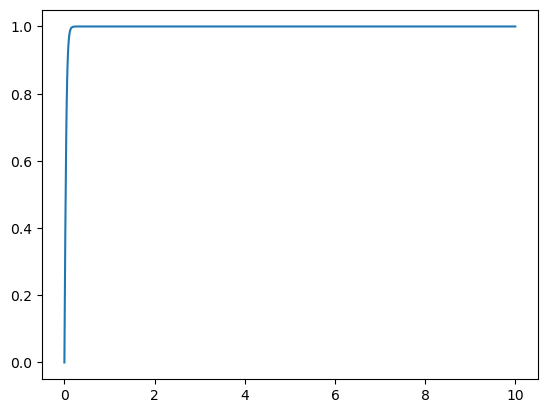

In [764]:
f=torch.tanh
ppp(f)

In [765]:
def softmax(x):
    """
    Computes the softmax function for a given numpy array.

    Args:
        x (numpy.ndarray): Input array.

    Returns:
        numpy.ndarray: Softmax output.
    """
    e_x = np.exp((x - np.max(x))) # Subtracting np.max(x) for numerical stability
    return e_x / e_x.sum(axis=0)

In [766]:
def pnormalize(x,p=2):
    """
    Computes the softmax function for a given numpy array.

    Args:
        x (numpy.ndarray): Input array.

    Returns:
        numpy.ndarray: Softmax output.
    """
    e_x = x**p # Subtracting np.max(x) for numerical stability
    return e_x #/ e_x.sum(axis=0)

In [767]:
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

Pin=np.array([[0.8,0.2],
[0.2,0.8],
[0.8,0.2],
[0.8,0.2]])

C=np.array([[0,19],
[7,0]])

Pout=np.array([[0.2,0.8],
[0.2,0.8],
[0.8,0.2],
[0.8,0.2]])


needs=E@Pin
print(needs)
#needs[needs!=0]=1
needs=pnormalize(needs)

print(needs)
costs=Pout@C
print(costs)

res2=needs*costs
print(np.sum(res2,axis=1))


[[2.6 1.4]
 [2.4 0.6]
 [1.8 1.2]
 [1.  1. ]]
[[6.76 1.96]
 [5.76 0.36]
 [3.24 1.44]
 [1.   1.  ]]
[[ 5.6  3.8]
 [ 5.6  3.8]
 [ 1.4 15.2]
 [ 1.4 15.2]]
[45.304 33.624 26.424 16.6  ]


## Create topolgies

In [768]:
import numpy as np
import topologies
import networkx as nx
import yaml
import json

In [769]:
def create_maps_from_E(N,E):
    #maps=np.full((N,N),10e10) #  99
    maps=np.full((N,N),99) #  99
    for i in range(N):
        maps[i,i]=0
    for (i,j,v) in E:
        maps[i,j]=v
        maps[j,i]=v
    return maps


In [770]:
def create_yaml_file(N, model_type, maps,costs=False):
    # valid: resnet18, resnet101
    if model_type == 'resnet18':
        layers_num = 20
        layers_str = "[inputs, conv1.weight, layer1.0.conv1.weight, layer1.0.conv2.weight, layer1.1.conv1.weight, layer1.1.conv2.weight, layer2.0.conv1.weight, layer2.0.conv2.weight, layer2.0.shortcut.0.weight, layer2.1.conv1.weight, layer2.1.conv2.weight, layer3.0.conv1.weight, layer3.0.conv2.weight, layer3.0.shortcut.0.weight, layer3.1.conv1.weight, layer3.1.conv2.weight, layer4.0.conv1.weight, layer4.0.conv2.weight, layer4.0.shortcut.0.weight, layer4.1.conv1.weight, layer4.1.conv2.weight]"

    if model_type == 'resnet101':
        layers_num = 70
        layers_str =  "[inputs, conv1.weight, layer1.0.conv1.weight, layer1.0.conv2.weight, layer1.1.conv1.weight, \
            layer1.1.conv2.weight, layer1.2.conv1.weight, layer1.2.conv2.weight, layer2.0.conv1.weight, \
            layer2.0.conv2.weight, layer2.0.shortcut.0.weight, layer2.1.conv1.weight, layer2.1.conv2.weight, \
            layer2.2.conv1.weight, layer2.2.conv2.weight, layer2.3.conv1.weight, layer2.3.conv2.weight, \
            layer3.0.conv1.weight, layer3.0.conv2.weight, layer3.0.shortcut.0.weight, layer3.1.conv1.weight, \
            layer3.1.conv2.weight, layer3.2.conv1.weight, layer3.2.conv2.weight, layer3.3.conv1.weight, \
            layer3.3.conv2.weight, layer3.4.conv1.weight, layer3.4.conv2.weight, layer3.5.conv1.weight, \
            layer3.5.conv2.weight, layer3.6.conv1.weight, layer3.6.conv2.weight, layer3.7.conv1.weight, \
            layer3.7.conv2.weight, layer3.8.conv1.weight, layer3.8.conv2.weight, layer3.9.conv1.weight, \
            layer3.9.conv2.weight, layer3.10.conv1.weight, layer3.10.conv2.weight, layer3.11.conv1.weight, \
            layer3.11.conv2.weight, layer3.12.conv1.weight, layer3.12.conv2.weight, layer3.13.conv1.weight, \
            layer3.13.conv2.weight, layer3.14.conv1.weight, layer3.14.conv2.weight, layer3.15.conv1.weight, \
            layer3.15.conv2.weight, layer3.16.conv1.weight, layer3.16.conv2.weight, layer3.17.conv1.weight, \
            layer3.17.conv2.weight, layer3.18.conv1.weight, layer3.18.conv2.weight, layer3.19.conv1.weight, \
            layer3.19.conv2.weight, layer3.20.conv1.weight, layer3.20.conv2.weight, layer3.21.conv1.weight, \
            layer3.21.conv2.weight, layer3.22.conv1.weight, layer3.22.conv2.weight, layer4.0.conv1.weight, \
            layer4.0.conv2.weight, layer4.0.shortcut.0.weight, layer4.1.conv1.weight, layer4.1.conv2.weight, \
            layer4.2.conv1.weight, layer4.2.conv2.weight]"  

    yaml_dict = {}
    yaml_dict['bn_partitions'] = [N] * 9
    initial_budget = [1] * N
    yaml_dict['budgets'] = np.tile(initial_budget, (layers_num, 1)).tolist()
    yaml_dict['initial_budget'] = initial_budget
    yaml_dict['input_partition'] = initial_budget
    yaml_dict['layers'] = layers_str
    yaml_dict['maps'] = maps.tolist() #np.array2string(maps, threshold=10000)
    yaml_dict['num'] = N
    yaml_str = json.dumps(yaml_dict)

    yaml_str = yaml_str.replace("\"", "")
    yaml_str = yaml_str.replace(", budgets: ", "\nbudgets: ")
    yaml_str = yaml_str.replace(", initial_budget: ", "\ninitial_budget: ")
    yaml_str = yaml_str.replace(", input_partition: ", "\ninput_partition: ")
    yaml_str = yaml_str.replace(", layers: ", "\nlayers: ")
    yaml_str = yaml_str.replace(", maps: ", "\nmaps: ")
    yaml_str = yaml_str.replace(", num: ", "\nnum: ")
    yaml_str = yaml_str.replace("{", "")
    yaml_str = yaml_str.replace("}", "")
    '''
    yaml_str = yaml_str.replace(", '", "\n'")
    yaml_str = yaml_str.replace("{", "")
    yaml_str = yaml_str.replace("}", "")
    yaml_str = yaml_str.replace("array(", "")
    yaml_str = yaml_str.replace("]])", "]]")
    yaml_str = yaml_str.replace("],", "]\n")
    '''
    yaml_str = yaml_str.replace("layer1.1.conv1.weight,", "layer1.1.conv1.weight,\n")
    yaml_str = yaml_str.replace("layer2.0.shortcut.0.weight,", "layer2.0.shortcut.0.weight,\n")
    yaml_str = yaml_str.replace("layer3.0.conv2.weight,", "layer3.0.conv2.weight,\n")
    yaml_str = yaml_str.replace("layer4.0.conv1.weight,", "layer4.0.conv1.weight,\n")

    yaml_str = yaml_str.replace("layer1.1.conv2.weight,", "        layer1.1.conv2.weight,")
    yaml_str = yaml_str.replace("layer2.1.conv1.weight,", "        layer2.1.conv1.weight,")
    yaml_str = yaml_str.replace("layer3.0.shortcut.0.weight,", "        layer3.0.shortcut.0.weight,")
    yaml_str = yaml_str.replace("layer4.0.conv2.weight", "        layer4.0.conv2.weight")
    '''
    yaml_str = yaml_str.replace("\"", "")
    yaml_str = yaml_str.replace(", maps: ", "\nmaps: ")
    '''
    if costs:
        yaml_filename = "./config/" + model_type + "-np" + str(N) + "-" + experiment_name + "_cost.yaml"
    else:
        yaml_filename = "./config/" + model_type + "-np" + str(N) + "-" + experiment_name + ".yaml"
    print(yaml_filename)
    with open(yaml_filename, 'w') as file:
        file.write(yaml_str)
    print(yaml_str)



In [771]:
costs=False
model_type = 'resnet101' # valid: resnet18, resnet101
experiment_name = 'Uniform' # valid: GEANT, Dtelekom, Abilene, ServiceNetwork, WattsStrogatz, BarabasiAlbert

if experiment_name == 'GEANT':
    graph = topologies.GEANT()
if experiment_name == 'Dtelekom':
    graph = topologies.Dtelekom()
if experiment_name == 'Abilene':
    graph = topologies.Abilene()
if experiment_name == 'ServiceNetwork':
    graph = topologies.ServiceNetwork()
if experiment_name == 'WattsStrogatz':
    graph = nx.watts_strogatz_graph(n=10, k=4, p=0.5)
if experiment_name == 'BarabasiAlbert':
    graph = nx.barabasi_albert_graph(n=10, m=4)
if experiment_name == 'Uniform':
    graph = nx.complete_graph(n=8)

In [772]:
print(graph.number_of_nodes())
N = graph.number_of_nodes()
print(graph.number_of_edges())
print(list(graph.nodes))
print(list(graph.edges))


8
28
[0, 1, 2, 3, 4, 5, 6, 7]
[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (3, 4), (3, 5), (3, 6), (3, 7), (4, 5), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7)]


In [773]:
for (source,target) in list(graph.edges):
        #print(source)
        graph[source][target]['weight'] = 1

In [774]:
if costs:
    #change weights
    np.random.seed(12)
    speeds=[0.5,1.5,2.5]
    speed_probs=[0.5,0.3,0.2]
    speed={}
    for s in list(graph.nodes):
        print(s,graph.degree(s))
        c=np.random.choice(speeds, 1, speed_probs)[0]
        speed[s]=c
    for (source,target) in list(graph.edges):
            #print(source)
            graph[source][target]['weight'] = speed[source]+speed[target]


In [775]:
maps=nx.floyd_warshall_numpy(graph)
maps

array([[0., 1., 1., 1., 1., 1., 1., 1.],
       [1., 0., 1., 1., 1., 1., 1., 1.],
       [1., 1., 0., 1., 1., 1., 1., 1.],
       [1., 1., 1., 0., 1., 1., 1., 1.],
       [1., 1., 1., 1., 0., 1., 1., 1.],
       [1., 1., 1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 1., 1., 0., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0.]])

In [776]:
create_yaml_file(N, model_type, maps,costs=costs)

./config/resnet101-np8-Uniform.yaml
bn_partitions: [8, 8, 8, 8, 8, 8, 8, 8, 8]
budgets: [[1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [

In [777]:
mapping = {}
i = 0
for node in list(graph.nodes):
    #print(node)
    mapping[node] = i
    i = i + 1
print(mapping)


{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7}


In [778]:
new_graph= nx.relabel_nodes(graph, mapping)
print(list(new_graph.nodes))
print(list(new_graph.edges))
nodes = list(new_graph.nodes)
edges = list(new_graph.edges)

[0, 1, 2, 3, 4, 5, 6, 7]
[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (3, 4), (3, 5), (3, 6), (3, 7), (4, 5), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7)]


In [779]:

E = []
y = (1,)
for edge in edges:
    edge += y
    E.append(edge)
print(E)


[(0, 1, 1), (0, 2, 1), (0, 3, 1), (0, 4, 1), (0, 5, 1), (0, 6, 1), (0, 7, 1), (1, 2, 1), (1, 3, 1), (1, 4, 1), (1, 5, 1), (1, 6, 1), (1, 7, 1), (2, 3, 1), (2, 4, 1), (2, 5, 1), (2, 6, 1), (2, 7, 1), (3, 4, 1), (3, 5, 1), (3, 6, 1), (3, 7, 1), (4, 5, 1), (4, 6, 1), (4, 7, 1), (5, 6, 1), (5, 7, 1), (6, 7, 1)]


In [780]:

G = nx.Graph()
G.add_weighted_edges_from(E)
maps=nx.floyd_warshall_numpy(G)
maps


array([[0., 1., 1., 1., 1., 1., 1., 1.],
       [1., 0., 1., 1., 1., 1., 1., 1.],
       [1., 1., 0., 1., 1., 1., 1., 1.],
       [1., 1., 1., 0., 1., 1., 1., 1.],
       [1., 1., 1., 1., 0., 1., 1., 1.],
       [1., 1., 1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 1., 1., 0., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0.]])

In [781]:

for (source,target) in list(G.edges):
        #print(source)
        G[source][target]['weight'] = 1


In [782]:

G[source][target]['weight'] = 1


In [783]:
#N=4
#E=[(0,1,1),(0,2,4),(2,3,1),(0,3,1)]
maps0 = create_maps_from_E(N,E)
maps0


array([[0, 1, 1, 1, 1, 1, 1, 1],
       [1, 0, 1, 1, 1, 1, 1, 1],
       [1, 1, 0, 1, 1, 1, 1, 1],
       [1, 1, 1, 0, 1, 1, 1, 1],
       [1, 1, 1, 1, 0, 1, 1, 1],
       [1, 1, 1, 1, 1, 0, 1, 1],
       [1, 1, 1, 1, 1, 1, 0, 1],
       [1, 1, 1, 1, 1, 1, 1, 0]])

In [784]:
maps

array([[0., 1., 1., 1., 1., 1., 1., 1.],
       [1., 0., 1., 1., 1., 1., 1., 1.],
       [1., 1., 0., 1., 1., 1., 1., 1.],
       [1., 1., 1., 0., 1., 1., 1., 1.],
       [1., 1., 1., 1., 0., 1., 1., 1.],
       [1., 1., 1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 1., 1., 0., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0.]])

In [785]:
budget = [0,0,0,0.2,0.2,0.2,0.2,0.2]
shape = 64

In [786]:
def fixsum(a,shape):
    total=np.sum(a)
    dif=shape-total
    d=np.sign(dif)
    c=0
    for i in range(a.size):
        if c>=np.abs(dif):
            break
        if a[i]!=0:
            a[i]+=d
            c+=1
    return a

In [787]:
absolute_counts = np.round(np.array(budget) * shape).astype(int)
a=fixsum(absolute_counts,shape)

In [788]:
absolute_counts

array([ 0,  0,  0, 12, 13, 13, 13, 13])

In [789]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)